# Simulated Data Challenge Events

This notebook examines the lightcurves and "truth" parameter table of the events simulated for the 2018 Microlensing Data Challenge. 

In [2]:
from os import path
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, Column
import parse_table1

Matthew Penny performed the simulation of the microlensing events for the challenge, and summarized their parameters in master_file.txt, which we load here. 

In [10]:
master_file = '/Users/rstreet/Roman/data-challenge-1/Answers/master_file.txt'
master_data = parse_table1.read_master_table(master_file)
print('Loaded information for ' + str(len(master_data)) + ' lightcurves')

Loaded information for 293 lightcurves


Firstly, we summarize the actual number of lightcurves in each category. 

In [13]:
lc_types = {}

for name, lc in master_data.items():
    if lc.model_class not in lc_types.keys():
        lc_types[lc.model_class] = [name]
    else:
        lc_types[lc.model_class].append(name)

nlc = 0
for cat, name_list in lc_types.items():
    print(cat + ': ' + str(len(name_list)))
    nlc += len(name_list) 

print('Total number of lightcurves: ' + str(nlc))

CV: 93
Binary_star: 83
Binary_planet: 43
PSPL: 74
Total number of lightcurves: 293


Next, we plot examples of each type of lightcurve.

In [16]:
PLOT_COLORS = {
    'W149': '#03A66A',
    'Z087': '#2E03A6'
}

In [34]:
def plot_lc(wlc, zlc, plot_file, title=None):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve

    Parameters:
        wlc  Table   Lightcurve data table for W146 filter 
        zlc  Table   Lightcurve data table for Z087 filter 
        plot_file  str    File path for saved PNG plot


    Returns:
        None, output lightcurve saved to plot_file
    """
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0
    
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['W149'], label='W149')
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-2450000.0 [days]', fontsize=18) 
    axs.set_ylabel('Mag', fontsize=18)
    if not title:
        axs.set_title('Lightcurve for event ' + eventID, fontsize=18)
    else:
        axs.set_title(title)
    axs.tick_params(axis='x', labelsize=16)
    axs.tick_params(axis='y', labelsize=16)
    
    axs.grid()
    axs.legend()
    
    axs.tick_params(axis='x', labelsize=16)
    axs.tick_params(axis='y', labelsize=16)
    
    plt.tight_layout()
    
    plt.savefig(plot_file)

In [77]:
def plot_lc_with_inset(wlc, zlc, inset_xmin, inset_xmax, plot_file, inset_left=0.35, inset_bottom=0.3, inset_width=0.6, inset_height=0.6, title=None):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve plus 
    an inset box showing a zoom in lightcurve around the event peak. 

    Parameters:
        wlc  Table   Lightcurve data table for W146 filter 
        zlc  Table   Lightcurve data table for Z087 filter 
        inset_xmin float  Minimum x-range of the inset axis 
        inset_ymax float  Maximum x-range of the inset axis
        plot_file  str    File path for saved PNG plot
        inset_left float  [optional] Left-edge coordinate of inset box relative to the main axis [0-1] 
        inset_bottom float [optional] Bottom-edge coordinate of inset box 
        inset_width float [optional] Width of the inset box 
        inset_height float [optional] Height of the inset box


    Returns:
        None, output lightcurve saved to plot_file
    """
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0
    
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['W149'], label='W149')
    axs.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ms=20, ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-2450000.0 [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    if not title:
        axs.set_title('Lightcurve for event ' + eventID, fontsize=20)
    else:
        axs.set_title(title, fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    axs.legend(fontsize=18)
    
    # Add inset axes; coordinates are 0-1 relative to main axis 
    ax_inset = axs.inset_axes([inset_left, inset_bottom, inset_width, inset_height])
    
    ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['W149'], label='W149')
    ax_inset.errorbar(wlc['JD']-dt, wlc['mag'], yerr=wlc['mag_err'], ls='none', c=PLOT_COLORS['Z087'], label='Z087')
    
    ax_inset.invert_yaxis()
    ax_inset.set_xlim(inset_xmin, inset_xmax)
    
    ax_inset.tick_params(axis='x', labelsize=18)
    ax_inset.tick_params(axis='y', labelsize=18)
    
    axs.tick_params(axis='x', labelsize=20)
    axs.tick_params(axis='y', labelsize=20)
    
    ax_inset.grid()

    plt.tight_layout()
    
    plt.savefig(plot_file)

In [78]:
def load_lc(file_path):
    """
    Function to load a lightcurve in the data challenge standard format. 

    Parameters:
        file_path str  Path to lightcurve text file 

    Returns:
        lc  Table   Lightcurve data table
    """

    if not path.isfile(file_path):
        raise IOError('Cannot find lightcurve file ' + file_path)

    data_table = Table.read(file_path, format='ascii')

    # Files do not contain column headers so we rename them for clarity
    data_table.rename_column('col1', 'JD')
    data_table.rename_column('col2', 'mag')
    data_table.rename_column('col3', 'mag_err')

    return data_table 

In [79]:
DATA_DIR = '/Users/rstreet/Roman/data-challenge-1/lc'

In [80]:
lc_types['CV']

['ulwdc1_001',
 'ulwdc1_003',
 'ulwdc1_007',
 'ulwdc1_010',
 'ulwdc1_011',
 'ulwdc1_013',
 'ulwdc1_015',
 'ulwdc1_016',
 'ulwdc1_019',
 'ulwdc1_023',
 'ulwdc1_024',
 'ulwdc1_026',
 'ulwdc1_030',
 'ulwdc1_034',
 'ulwdc1_035',
 'ulwdc1_036',
 'ulwdc1_037',
 'ulwdc1_044',
 'ulwdc1_048',
 'ulwdc1_049',
 'ulwdc1_051',
 'ulwdc1_055',
 'ulwdc1_061',
 'ulwdc1_064',
 'ulwdc1_075',
 'ulwdc1_082',
 'ulwdc1_083',
 'ulwdc1_086',
 'ulwdc1_088',
 'ulwdc1_090',
 'ulwdc1_096',
 'ulwdc1_098',
 'ulwdc1_106',
 'ulwdc1_109',
 'ulwdc1_110',
 'ulwdc1_112',
 'ulwdc1_122',
 'ulwdc1_126',
 'ulwdc1_129',
 'ulwdc1_130',
 'ulwdc1_132',
 'ulwdc1_134',
 'ulwdc1_135',
 'ulwdc1_137',
 'ulwdc1_138',
 'ulwdc1_141',
 'ulwdc1_145',
 'ulwdc1_155',
 'ulwdc1_161',
 'ulwdc1_164',
 'ulwdc1_165',
 'ulwdc1_173',
 'ulwdc1_176',
 'ulwdc1_177',
 'ulwdc1_178',
 'ulwdc1_180',
 'ulwdc1_183',
 'ulwdc1_187',
 'ulwdc1_195',
 'ulwdc1_196',
 'ulwdc1_197',
 'ulwdc1_200',
 'ulwdc1_201',
 'ulwdc1_202',
 'ulwdc1_203',
 'ulwdc1_206',
 'ulwdc1_2

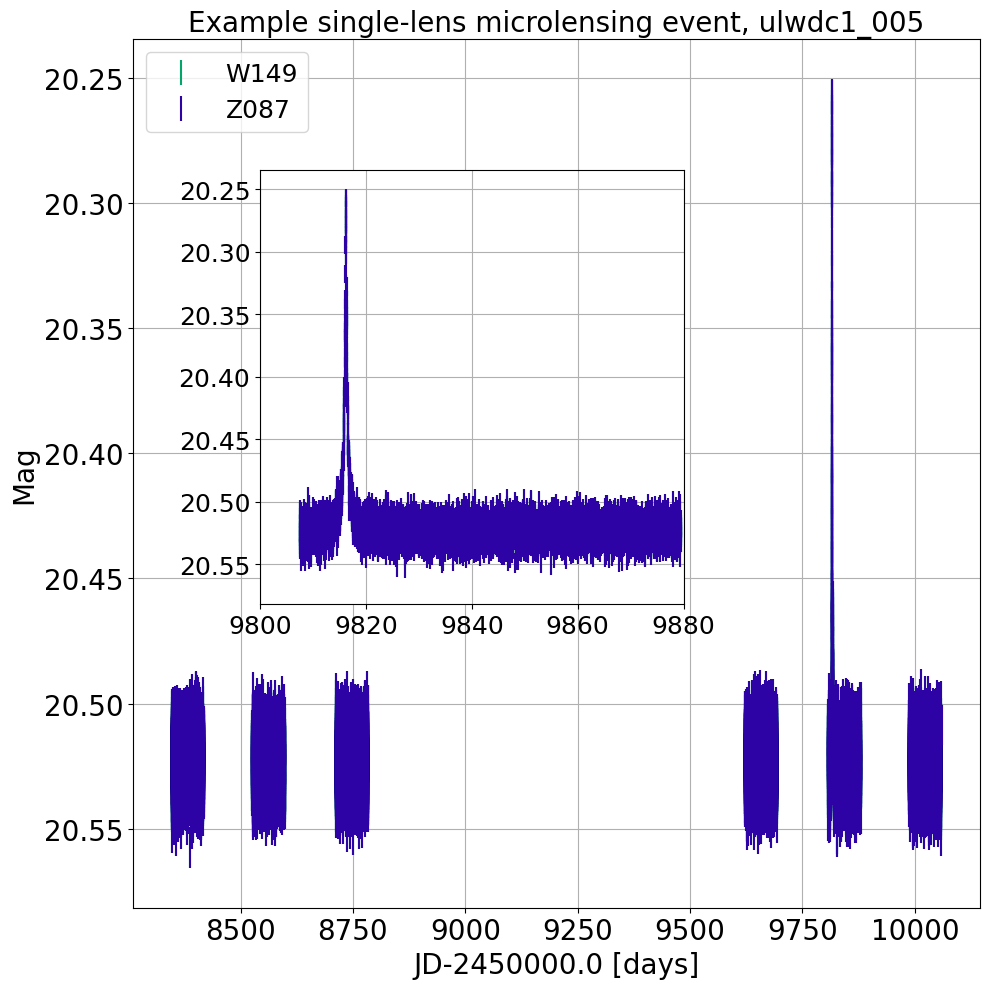

In [82]:
# Example of PSPL event
eventID = 'ulwdc1_005'
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')
wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc_with_inset(wlc, zlc, 9800.0, 9880.0, plot_file, inset_left=0.15, inset_bottom=0.35, inset_width=0.5, inset_height=0.5, 
                  title='Example single-lens microlensing event, ' + eventID)

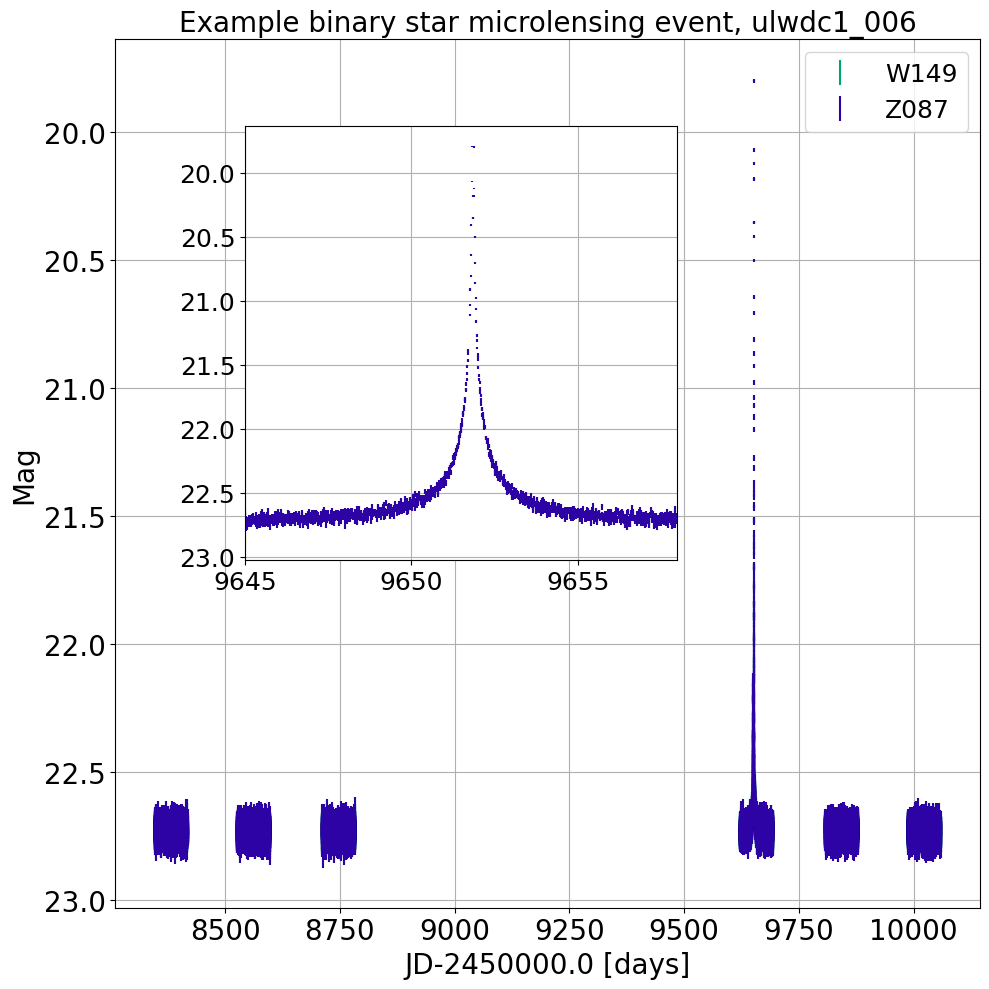

In [83]:
# Example of Binary_star event
eventID = 'ulwdc1_006'
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')
wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc_with_inset(wlc, zlc, 9645.0, 9658.0, plot_file, inset_left=0.15, inset_bottom=0.4, inset_width=0.5, inset_height=0.5, 
                  title='Example binary star microlensing event, ' + eventID)

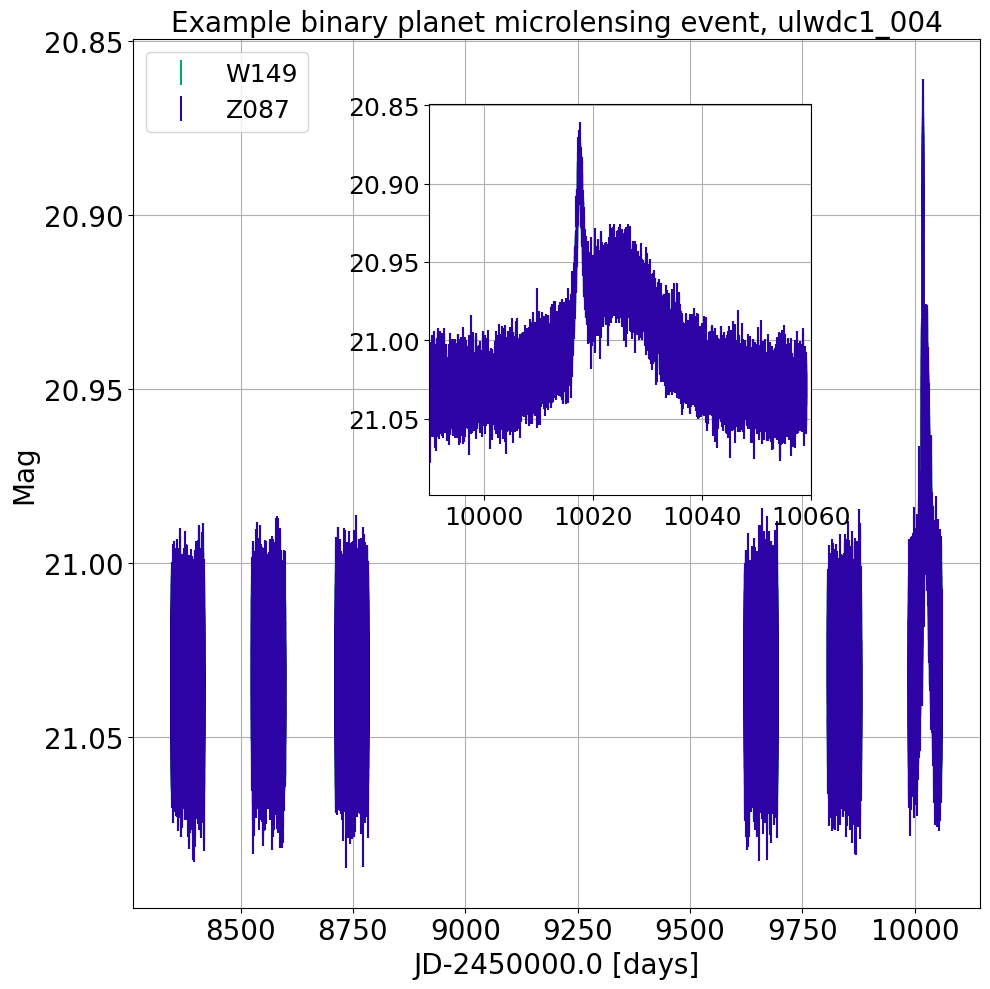

In [87]:
# Example of a binary planet event
eventID = 'ulwdc1_004'
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')
wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc_with_inset(wlc, zlc, 9990.0, 10060.0, plot_file, inset_left=0.35, inset_bottom=0.475, inset_width=0.45, inset_height=0.45, 
                  title='Example binary planet microlensing event, ' + eventID)

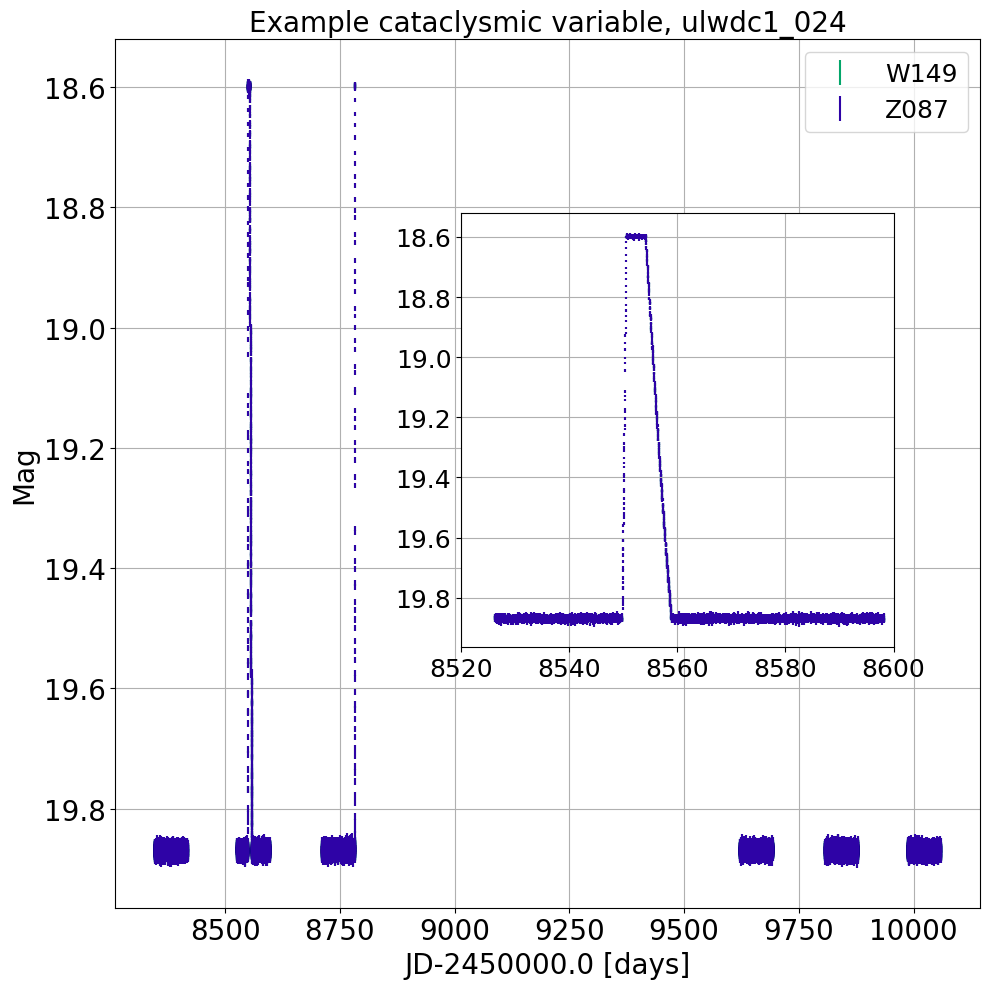

In [89]:
# Example of a CV
eventID = 'ulwdc1_024'
wlc_path = path.join(DATA_DIR, eventID + '_W149.txt')
zlc_path = path.join(DATA_DIR, eventID + '_Z087.txt')
wlc = load_lc(wlc_path)
zlc = load_lc(zlc_path)
plot_file = path.join(DATA_DIR, eventID + '_lc.png')
plot_lc_with_inset(wlc, zlc, 8520.0, 8600.0, plot_file, inset_left=0.4, inset_bottom=0.3, inset_width=0.5, inset_height=0.5, 
                  title='Example cataclysmic variable, ' + eventID)

## Parameter ranges 

Here we check the ranges covered by the true parameter values

In [90]:
# Full list of parameter attributes
par_list = ['t0', 'tE', 'u0', 'rho', 'piE', \
                'fs_W', 'fb_W', 'fs_Z', 'fb_Z', \
                's', 'q', 'alpha', 'dsdt', 'dadt', 'M1', 'M2', 'DL', 'DS', 'aperp']

In [95]:
for par in par_list:
    min_value = 1e8
    max_value = -1e8
    for name,lc in master_data.items():
        val = getattr(lc, par)
        if val:
            min_value = min(min_value, val)
            max_value = max(max_value, val)
    print(par, min_value, max_value)

t0 2458338.831308834 2460069.96441925
tE 0.0178673 192.463
u0 -2.13817 2.31029
rho 0.000129089 1.50022
piE 0.0128661 54.5325
fs_W 0.000618449 0.999593
fb_W 0.3088950916713404 1349445.200809845
fs_Z 0.000773399 0.999686
fb_Z 0.34500697896763144 865839.5874680758
s 0.113947 19.6097
q 1.65609e-06 0.972877
alpha 3.48269 357.186
dsdt -0.048091410581077305 -5.1404693822085794e-05
dadt -5.535840131533309 -0.00011942652569956636
M1 0.08 1.197
M2 8.28044e-07 1.04728
DL 2.186 10.984
DS 4.45 14.761
aperp 0.139503 150.464
